## Programming Assignment 50039271 Cao Hanyu
### Import Required Libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

### Load and Preprocess the MNIST Dataset
I load the MNIST dataset, which contains 70,000 28x28 grayscale images of digits 0 through 9. I flatten the 28x28 images into 784-dimensional vectors, normalize pixel values to the range [0, 1] by dividing 255, split the full dataset into an 80% training set and 20% test set, then further split the training set into a 90% training subset and 10% validation subset for hyperparameter tuning and overfitting monitoring. I apply one-hot encoding to the labels to match the output format of the network.

In [2]:
def load_and_preprocess_mnist():
    print("Loading MNIST dataset...")
    # Load MNIST dataset from openml
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X, y = mnist.data, mnist.target.astype(int)
    
    # Normalize pixel values to the range [0, 1]
    X = X / 255.0
    
    # Split full dataset into training (80%) and test (20%) sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # One-hot encode labels for multi-class classification
    onehot_encoder = OneHotEncoder(sparse_output=False)
    y_train_onehot = onehot_encoder.fit_transform(y_train.reshape(-1, 1))
    y_test_onehot = onehot_encoder.transform(y_test.reshape(-1, 1))
    
    # Split training set into training (90%) and validation (10%) sets
    X_train, X_val, y_train_onehot, y_val_onehot, y_train, y_val = train_test_split(
        X_train, y_train_onehot, y_train, test_size=0.1, random_state=42
    )
    
    # Print dataset split information for verification
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Validation set size: {X_val.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")
    
    return X_train, y_train_onehot, X_val, y_val_onehot, X_test, y_test_onehot, y_test

### Implement the Connected Neural Network Class
This code implements a fully connected neural network class (FullyConnectedNN) from scratch using NumPy, fully encapsulating the core processes of deep learning model training and inference: upon class initialisation, it supports custom network layer structures, activation functions (ReLU/Softmax) and optimisers (SGD/Adam), with parameters initialised using He to mitigate the vanishing gradient problem.

It implements numerically stable forward propagation, which avoids numerical overflow during the computation of linear combinations and activation outputs (especially for the Softmax function at the output layer, where a shift operation is applied to the linear output Z by subtracting its maximum value to prevent exponentiation of large values from causing numerical instability). It also includes the calculation of categorical cross-entropy loss, which effectively measures the discrepancy between predicted class probabilities and true labels, and a small epsilon value is added to the loss computation to avoid numerical errors caused by taking the logarithm of zero. Additionally, it completes the derivation and computation of gradients through backpropagation based on the chain rule, starting from the output layer to compute the gradient of the loss with respect to the output, then propagating this gradient backward through all hidden layers to accurately calculate the gradients of weights and biases for each layer, laying a solid foundation for subsequent parameter updates. 

It supports parameter updates using the Adam adaptive optimiser with momentum and bias correction. The `fit` method provides mini-batch training, training set shuffling and real-time validation set evaluation, whilst the `predict` and `evaluate` methods are used to generate prediction results and calculate classification accuracy respectively.r metric for model effectiveness.

In [3]:
class FullyConnectedNN:
    # Class Initialization
    def __init__(self, layer_sizes, activation='relu', output_activation='softmax', 
             learning_rate=0.01, optimizer='sgd', beta1=0.9, beta2=0.999, epsilon=1e-8):
        # Network Configuration
        self.layer_sizes = layer_sizes
        self.activation_name = activation
        self.output_activation_name = output_activation
        # Training hyperparameters
        self.lr = learning_rate
        self.optimizer_type = optimizer
    
        # Adam optimizer hyperparameters
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0  # Time step for Adam bias correction
        
        # Storage for model weights and biases
        self.parameters = {}
        # Storage for Adam optimizer moment vectors
        self.m = {}  # First moment estimate
        self.v = {}  # Second raw moment estimate
        # Initialize model parameters
        self._initialize_parameters()

    # Parameter Initialization
    def _initialize_parameters(self):
        # Set random seed
        np.random.seed(42)
        # Initialize weights and biases
        for layer_idx in range(1, len(self.layer_sizes)):
            # He initialization for weight matrices
            self.parameters[f'W{layer_idx}'] = np.random.randn(
                self.layer_sizes[layer_idx-1], self.layer_sizes[layer_idx]
            ) * np.sqrt(2. / self.layer_sizes[layer_idx-1])
            # Zero initialization for bias vectors
            self.parameters[f'b{layer_idx}'] = np.zeros((1, self.layer_sizes[layer_idx]))
            
            # Initialize moment vectors when use Adam optimizer
            if self.optimizer_type == 'adam':
                self.m[f'W{layer_idx}'] = np.zeros_like(self.parameters[f'W{layer_idx}'])
                self.m[f'b{layer_idx}'] = np.zeros_like(self.parameters[f'b{layer_idx}'])
                self.v[f'W{layer_idx}'] = np.zeros_like(self.parameters[f'W{layer_idx}'])
                self.v[f'b{layer_idx}'] = np.zeros_like(self.parameters[f'b{layer_idx}'])

    #Activation Functions and Derivatives
    def _activation(self, Z, activation_name):
        # ReLU activation for hidden layers
        if activation_name == 'relu':
            return np.maximum(0, Z)
        # Numerically stable Softmax activation for output layer
        elif activation_name == 'softmax':
            Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
            exp_Z = np.exp(Z_shifted)
            return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
        # Linear activation fallback
        return Z

    def _activation_derivative(self, Z, activation_name):
        # Derivative of ReLU activation function
        if activation_name == 'relu':
            return (Z > 0).astype(float)
        # Derivative of linear activation
        return 1.0

    #Forward Propagation
    def forward_propagation(self, X):
        # Store intermediate values for backward propagation
        cache = {'A0': X}
        total_layers = len(self.layer_sizes) - 1
        
        # Forward pass for all hidden layers
        for layer_idx in range(1, total_layers):
            cache[f'Z{layer_idx}'] = np.dot(
                cache[f'A{layer_idx-1}'], self.parameters[f'W{layer_idx}']
            ) + self.parameters[f'b{layer_idx}']
            cache[f'A{layer_idx}'] = self._activation(
                cache[f'Z{layer_idx}'], self.activation_name
            )
        
        # Forward pass for the final output layer
        cache[f'Z{total_layers}'] = np.dot(
            cache[f'A{total_layers-1}'], self.parameters[f'W{total_layers}']
        ) + self.parameters[f'b{total_layers}']
        cache[f'A{total_layers}'] = self._activation(
            cache[f'Z{total_layers}'], self.output_activation_name
        )
        
        return cache

    #Categorical Cross-Entropy Loss Calculation
    def compute_loss(self, Y_pred, Y_true):
        num_samples = Y_true.shape[0]
        # Add epsilon to prevent log(0) numerical instability
        log_likelihood = -np.log(Y_pred[range(num_samples), Y_true.argmax(axis=1)] + 1e-8)
        # Average loss over all samples in the batch
        loss = np.sum(log_likelihood) / num_samples
        return loss

    #Backward Propagation
    def backward_propagation(self, cache, Y):
        gradients = {}
        total_layers = len(self.layer_sizes) - 1
        num_samples = cache['A0'].shape[0]
        
        # Convert labels to one-hot format if input is class indices
        if Y.ndim == 1:
            Y_one_hot = np.zeros((num_samples, self.layer_sizes[-1]))
            Y_one_hot[np.arange(num_samples), Y] = 1
        else:
            Y_one_hot = Y
        
        # Compute gradient for the output layer
        dZ = cache[f'A{total_layers}'] - Y_one_hot
        gradients[f'dW{total_layers}'] = np.dot(cache[f'A{total_layers-1}'].T, dZ) / num_samples
        gradients[f'db{total_layers}'] = np.sum(dZ, axis=0, keepdims=True) / num_samples
        
        # Backpropagate gradients through all hidden layers
        for layer_idx in range(total_layers-1, 0, -1):
            dA = np.dot(dZ, self.parameters[f'W{layer_idx+1}'].T)
            dZ = dA * self._activation_derivative(cache[f'Z{layer_idx}'], self.activation_name)
            gradients[f'dW{layer_idx}'] = np.dot(cache[f'A{layer_idx-1}'].T, dZ) / num_samples
            gradients[f'db{layer_idx}'] = np.sum(dZ, axis=0, keepdims=True) / num_samples
            
        return gradients

    #Parameter Update with Optimizers
    def _update_parameters(self, gradients):
        total_layers = len(self.layer_sizes) - 1
        
        # Mini-batch SGD update
        if self.optimizer_type == 'sgd':
            for layer_idx in range(1, total_layers+1):
                self.parameters[f'W{layer_idx}'] -= self.lr * gradients[f'dW{layer_idx}']
                self.parameters[f'b{layer_idx}'] -= self.lr * gradients[f'db{layer_idx}']
                
        # Adam optimizer update
        # The Adam optimizer is an adaptive learning rate method that maintains first and second moment estimates of gradients, 
        # includes bias correction for early training steps, 
        # and adapts the learning rate for each parameter individually, 
        # leading to faster and more stable convergence compared to standard SGD.
        elif self.optimizer_type == 'adam':
            self.t += 1
            for layer_idx in range(1, total_layers+1):
                # Update biased first moment estimate
                self.m[f'W{layer_idx}'] = self.beta1 * self.m[f'W{layer_idx}'] + (1 - self.beta1) * gradients[f'dW{layer_idx}']
                self.m[f'b{layer_idx}'] = self.beta1 * self.m[f'b{layer_idx}'] + (1 - self.beta1) * gradients[f'db{layer_idx}']
                
                # Update biased second raw moment estimate
                self.v[f'W{layer_idx}'] = self.beta2 * self.v[f'W{layer_idx}'] + (1 - self.beta2) * (gradients[f'dW{layer_idx}'] ** 2)
                self.v[f'b{layer_idx}'] = self.beta2 * self.v[f'b{layer_idx}'] + (1 - self.beta2) * (gradients[f'db{layer_idx}'] ** 2)
                
                # Apply bias correction for moment estimates
                m_hat_W = self.m[f'W{layer_idx}'] / (1 - self.beta1 ** self.t)
                v_hat_W = self.v[f'W{layer_idx}'] / (1 - self.beta2 ** self.t)
                m_hat_b = self.m[f'b{layer_idx}'] / (1 - self.beta1 ** self.t)
                v_hat_b = self.v[f'b{layer_idx}'] / (1 - self.beta2 ** self.t)
                
                # Update parameters with adaptive learning rate
                self.parameters[f'W{layer_idx}'] -= self.lr * m_hat_W / (np.sqrt(v_hat_W) + self.epsilon)
                self.parameters[f'b{layer_idx}'] -= self.lr * m_hat_b / (np.sqrt(v_hat_b) + self.epsilon)

    # Model Training with Mini-Batch Learning
    def fit(self, X, y, epochs=100, batch_size=64, validation_data=None):
        # Store training history for plotting and analysis
        history = {'loss': [], 'val_acc': []}
        num_samples = X.shape[0]
        
        for epoch in range(epochs):
            # Shuffle training data at the start of each epoch
            permutation = np.random.permutation(num_samples)
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]
            
            epoch_total_loss = 0
            num_batches = 0
            
            # Iterate over all mini-batches
            for i in range(0, num_samples, batch_size):
                # Extract the current mini-batch
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # Forward propagation pass
                batch_cache = self.forward_propagation(X_batch)
                # Calculate loss for the current batch
                batch_loss = self.compute_loss(batch_cache[f'A{len(self.layer_sizes)-1}'], y_batch)
                # Backward propagation to compute gradients
                batch_gradients = self.backward_propagation(batch_cache, y_batch)
                # Update model parameters using the computed gradients
                self._update_parameters(batch_gradients)
                
                # Accumulate loss for the epoch
                epoch_total_loss += batch_loss
                num_batches += 1
            
            # Calculate average loss for the completed epoch
            avg_epoch_loss = epoch_total_loss / num_batches
            history['loss'].append(avg_epoch_loss)
            
            # Evaluate model on validation set if provided
            if validation_data:
                val_accuracy = self.evaluate(validation_data[0], validation_data[1])
                history['val_acc'].append(val_accuracy)
                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_epoch_loss:.4f} | Validation Accuracy: {val_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_epoch_loss:.4f}")
                
        return history

    #Prediction and Model Evaluation
    def predict(self, X):
        # Forward propagation to get class probabilities
        cache = self.forward_propagation(X)
        # Return the class with the highest predicted probability
        return np.argmax(cache[f'A{len(self.layer_sizes)-1}'], axis=1)

    def evaluate(self, X, y):
        # Get model predictions for input data
        predictions = self.predict(X)
        # Convert one-hot encoded labels to class indices if needed
        true_labels = y.argmax(axis=1) if y.ndim == 2 else y
        # Calculate overall classification accuracy
        accuracy = np.mean(predictions == true_labels)
        return accuracy

### Train Baseline Model with Mini-Batch SGD

In [4]:
# Load and preprocess the full MNIST dataset
X_train, y_train_onehot, X_val, y_val_onehot, X_test, y_test_onehot, y_test = load_and_preprocess_mnist()

# Define the network architecture
layer_sizes = [784, 256, 128, 10]

# Train baseline model with mini-batch SGD
print("\n=== Training Baseline Model with Mini-Batch SGD ===")
model_sgd = FullyConnectedNN(
    layer_sizes=layer_sizes,
    learning_rate=0.1,
    optimizer='sgd'
)
history_sgd = model_sgd.fit(
    X_train, y_train_onehot,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val_onehot),
)

# Evaluate SGD baseline model on the test set
sgd_test_accuracy = model_sgd.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy (SGD): {sgd_test_accuracy:.4f}")

Loading MNIST dataset...
Training set size: 50400 samples
Validation set size: 5600 samples
Test set size: 14000 samples

=== Training Baseline Model with Mini-Batch SGD ===
Epoch 5/50 | Loss: 0.1012 | Validation Accuracy: 0.9620
Epoch 10/50 | Loss: 0.0500 | Validation Accuracy: 0.9720
Epoch 15/50 | Loss: 0.0264 | Validation Accuracy: 0.9771
Epoch 20/50 | Loss: 0.0142 | Validation Accuracy: 0.9761
Epoch 25/50 | Loss: 0.0085 | Validation Accuracy: 0.9770
Epoch 30/50 | Loss: 0.0052 | Validation Accuracy: 0.9764
Epoch 35/50 | Loss: 0.0035 | Validation Accuracy: 0.9782
Epoch 40/50 | Loss: 0.0025 | Validation Accuracy: 0.9788
Epoch 45/50 | Loss: 0.0020 | Validation Accuracy: 0.9788
Epoch 50/50 | Loss: 0.0016 | Validation Accuracy: 0.9793

Final Test Accuracy (SGD): 0.9754


The accuracy reach 97.54%

### Train Model with Adam Optimizer

In [5]:
# Train model with Adam optimizer
print("\n=== Training Model with Adam Optimizer ===")
model_adam = FullyConnectedNN(
    layer_sizes=layer_sizes,
    learning_rate=0.001,
    optimizer='adam'
)
history_adam = model_adam.fit(
    X_train, y_train_onehot,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val_onehot),
)

# Evaluate Adam model on the held-out test set
adam_test_accuracy = model_adam.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy (Adam Optimizer): {adam_test_accuracy:.4f}")


=== Training Model with Adam Optimizer ===
Epoch 5/50 | Loss: 0.0360 | Validation Accuracy: 0.9754
Epoch 10/50 | Loss: 0.0110 | Validation Accuracy: 0.9809
Epoch 15/50 | Loss: 0.0079 | Validation Accuracy: 0.9798
Epoch 20/50 | Loss: 0.0087 | Validation Accuracy: 0.9750
Epoch 25/50 | Loss: 0.0036 | Validation Accuracy: 0.9775
Epoch 30/50 | Loss: 0.0063 | Validation Accuracy: 0.9780
Epoch 35/50 | Loss: 0.0069 | Validation Accuracy: 0.9796
Epoch 40/50 | Loss: 0.0000 | Validation Accuracy: 0.9823
Epoch 45/50 | Loss: 0.0000 | Validation Accuracy: 0.9821
Epoch 50/50 | Loss: 0.0000 | Validation Accuracy: 0.9820

Final Test Accuracy (Adam Optimizer): 0.9819


### Visualize Training Results

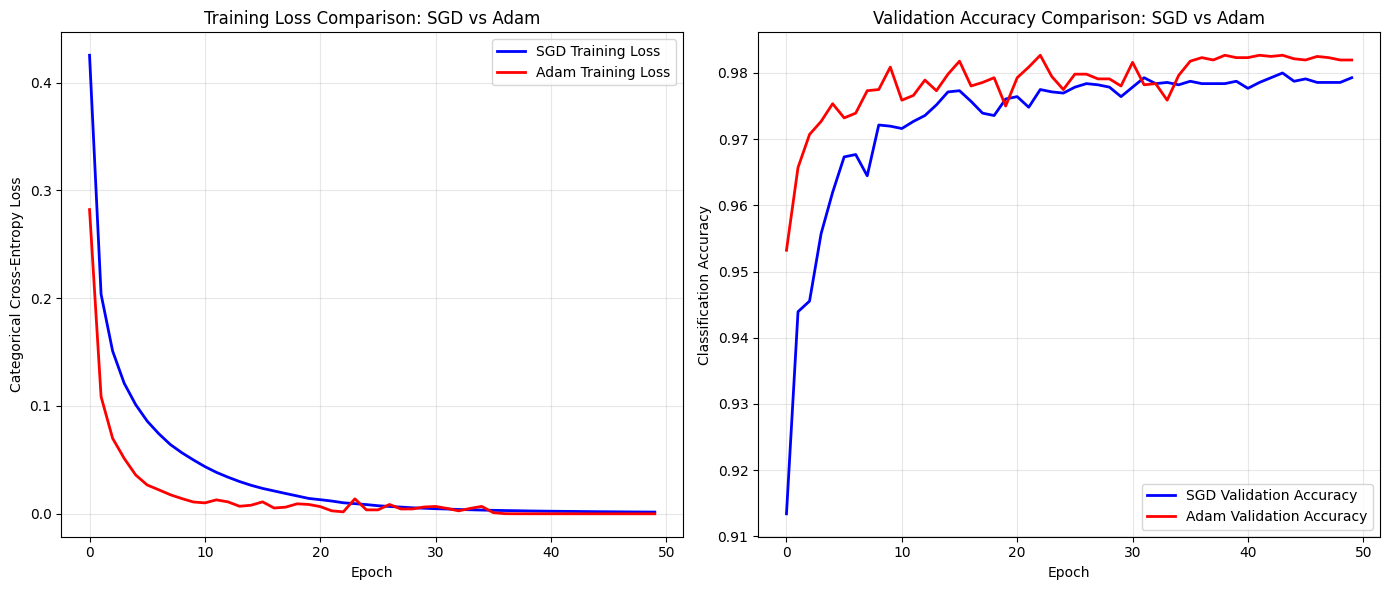

In [6]:
# Create side-by-side comparison plots for training results
plt.figure(figsize=(14, 6))

# Plot training loss comparison
plt.subplot(1, 2, 1)
plt.plot(history_sgd['loss'], label='SGD Training Loss', color='blue', linewidth=2)
plt.plot(history_adam['loss'], label='Adam Training Loss', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.title('Training Loss Comparison: SGD vs Adam')
plt.legend()
plt.grid(alpha=0.3)

# Plot validation accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(history_sgd['val_acc'], label='SGD Validation Accuracy', color='blue', linewidth=2)
plt.plot(history_adam['val_acc'], label='Adam Validation Accuracy', color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy')
plt.title('Validation Accuracy Comparison: SGD vs Adam')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=300)
plt.show()

The experimental results show that the Adam optimizer outperforms mini-batch SGD. Adam achieves faster loss reduction and quicker accuracy improvement during training. It maintains higher validation accuracy across epochs, and finally reaches a test accuracy of 0.9819, higher than SGD’s 0.9754. This indicates Adam provides better convergence speed and superior generalization performance for this MNIST classification task.